In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from risk_metrics import historical_var, historical_es

In [3]:
# ETFs to analyze
tickers = [
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000
    "EEM",   # Emerging markets
    "TLT",   # long-term treasury bond
    "GLD"    # gold commodity
]

prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

log_returns = np.log(prices / prices.shift(1)).dropna()

print(prices.head())
print(log_returns.head())

Ticker            EEM         GLD         IWM        QQQ         SPY  \
Date                                                                   
2015-01-02  30.355045  114.080002  102.969826  94.784447  170.589584   
2015-01-05  29.814814  115.800003  101.593201  93.394089  167.508820   
2015-01-06  29.689531  117.120003   99.835594  92.141785  165.931030   
2015-01-07  30.331562  116.430000  101.065094  93.329597  167.998779   
2015-01-08  30.848312  115.940002  102.779343  95.115906  170.979935   

Ticker            TLT  
Date                   
2015-01-02  94.446419  
2015-01-05  95.930016  
2015-01-06  97.658401  
2015-01-07  97.465508  
2015-01-08  96.174797  
Ticker           EEM       GLD       IWM       QQQ       SPY       TLT
Date                                                                  
2015-01-05 -0.017957  0.014965 -0.013459 -0.014777 -0.018225  0.015586
2015-01-06 -0.004211  0.011334 -0.017452 -0.013500 -0.009464  0.017857
2015-01-07  0.021394 -0.005909  0.012240  0

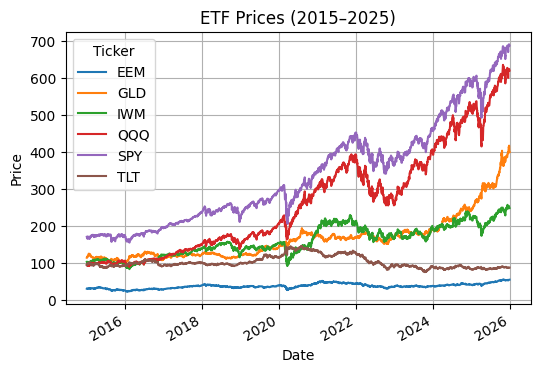

In [4]:
prices.plot(figsize=(6,4), title="ETF Prices (2015–2025)")
plt.ylabel("Price")
plt.grid(True)
plt.show()

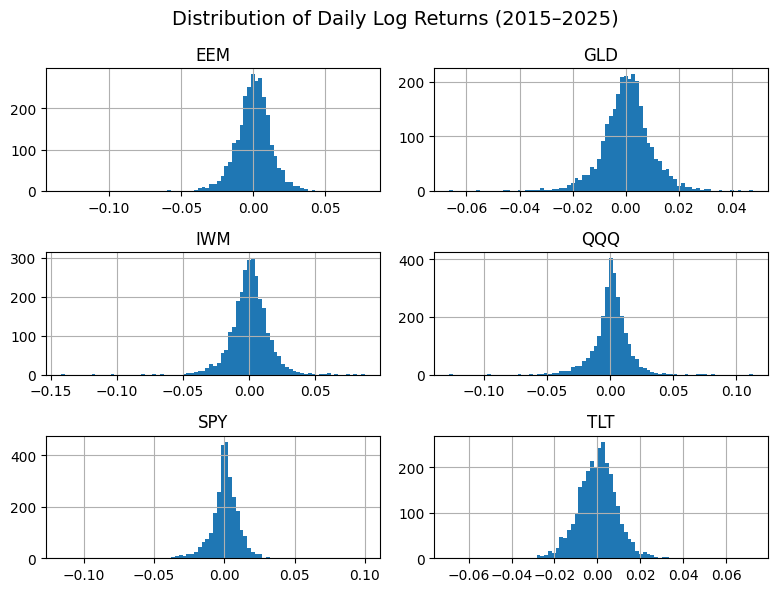

In [5]:
log_returns.hist(
    bins=80,
    figsize=(8,6),
    grid=True
)

plt.suptitle("Distribution of Daily Log Returns (2015–2025)", fontsize=14)

plt.tight_layout()
plt.show()

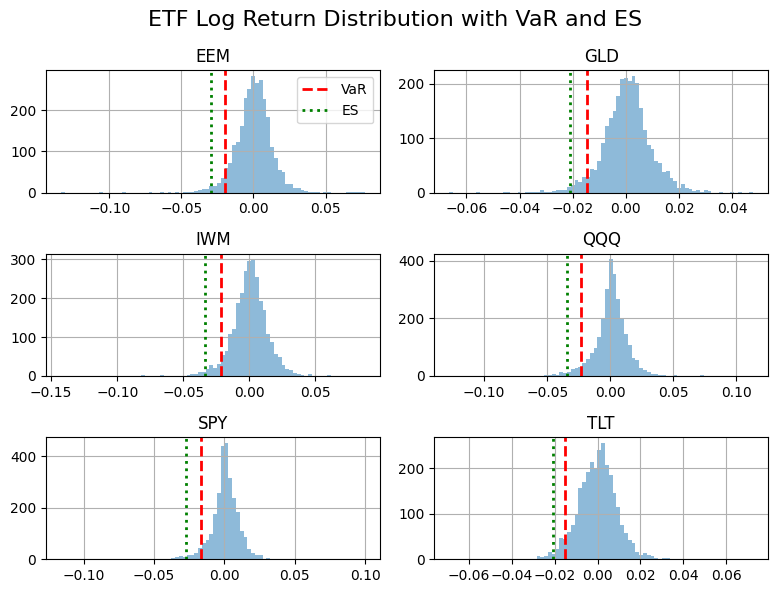

In [9]:
import matplotlib.pyplot as plt

alpha = 0.05

fig, axes = plt.subplots(3, 2, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(log_returns.columns):

    returns = log_returns[col].dropna()

    var = -historical_var(returns, alpha)
    es = -historical_es(returns, alpha)

    ax = axes[i]

    ax.hist(returns, bins=80, alpha=0.5)

    ax.axvline(var, linestyle="--", color='r', linewidth=2, label="VaR")
    ax.axvline(es, linestyle=":", color='g', linewidth=2, label="ES")

    ax.set_title(col)
    ax.grid(True)

fig.suptitle("ETF Log Return Distribution with VaR and ES", fontsize=16)

# show legend only once
axes[0].legend()

plt.tight_layout()
plt.show()